In [1]:
import pyomo.environ as pyo
import idaes
import math
import pandas as pd
import numpy as np
from scipy import stats
import pyomo.dae as dae
import matplotlib.pyplot as plt
from pyomo.contrib.parmest.experiment import Experiment
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.contrib.parmest import parmest
from scipy.stats import chi2
import matplotlib.lines as mlines
from matplotlib.patches import Patch

# Create the class and functions to be used in this notebook

In [39]:
class BatchReactorExperiment(Experiment):
    """Creates and labels the Pyomo model of the batch reactor
    
    Parameters
    ----------
    data: Pandas.DataFrame or .csv file,
        Data containing the sample time and measured values of mass fractions 
    XA0: float,
        Initial mass fraction of species A
    temp_control: int, float, list, or dict,
        Constant or piecewise-linear profile of the reaction temperature (in R)
    const_temp: Boolean,
        Species if the batch reactor is a constant or variable temperature system
    doe_solve: Boolean,
        Species if the batch reactor model is being used for optimal experimental design

    Returns
    -------
    m: annotated Pyomo model of the batch reactor
    """

    def __init__(self, XA0, temp_control, const_temp, data=None, doe_solve=False,):
        self.data = data
        self.XA0 = XA0
        self.temp_control = temp_control
        self.const_temp = const_temp
        self.doe_solve = doe_solve
        self.model = None

    def get_labeled_model(self):
        self.create_model()
        self.label_model()

        return self.model

    def create_model(self):
        if self.const_temp and not self.doe_solve:
            self.model = reform_const_temp_reactor_model(self.XA0, self.temp_control)
        elif not self.const_temp and self.doe_solve:
            self.model = reform_optimal_exp_design_model(self.XA0, self.temp_control)

        return self.model

    def label_model(self):

        m = self.model
        
        meas_time_points = self.data["Time (hr)"]
    
        # label the measured variables
        m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_outputs.update(
            (m.XA[t], self.data["XA"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XB[t], self.data["XB"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XC[t], self.data["XC"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XP[t], self.data["XP"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XE[t], self.data["XE"][ind]) for ind, t in enumerate(meas_time_points)
        )
        m.experiment_outputs.update(
            (m.XG[t], self.data["XG"][ind]) for ind, t in enumerate(meas_time_points)
        )
        
        # add the measurement errors
        m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.measurement_error.update(
            (m.XA[t], 0.001) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XB[t], 0.001) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XC[t], 0.001) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XP[t], 0.01) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XE[t], 0.01) for t in meas_time_points
        )
        m.measurement_error.update(
            (m.XG[t], 0.01) for t in meas_time_points
        )

        # label the unknown parameters
        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (k, pyo.value(k)) for k in [m.alpha_1, m.alpha_2, m.alpha_3, m.E1, m.E2, m.E3]
        )

        return m

In [3]:
def parameter_covariance_est(exp_list, const_temp=False):
    """Estimates the parameters and covariance matrix of the batch reactor model 
    from the data

    Parameters
    ----------
    exp_list: list,
        List containing the BatchReactorExperiment object
    const_temp: Boolean,
        Species if the batch reactor is a constant or variable temperature system

    Returns
    -------
    obj: float or int,
        Value of the objective function at the estimated parameters
    theta: dict, 
        Estimated values of the model parameters
    cov: pandas.DataFrame, 
        Covariance matrix of the estimated model parameters
    """

    # create the Estimator object
    pest = parmest.Estimator(exp_list, obj_function="SSE_weighted", tee=True)
    
    # estimate the parameters
    obj, theta = pest.theta_est()

    # compute the covariance matrix of the estimated parameters
    try:
        if const_temp:
            cov = pest.cov_est(method="automatic_differentiation_kaug", step=1e-5)
        else:
            cov = pest.cov_est(method="automatic_differentiation_kaug")

        return obj, theta, cov
    except RuntimeError:
        return obj, theta, ["N/A"]
    
    
    

In [4]:
def ground_truth_data(measured_var):
    """Creates a Pandas dataframe for ground-truth simulation of mass fractions

    Parameters
    ----------
    measured_var: 2D numpy array or matrix,
        matrix containing ground-truth simulation of mass fractions

    Returns
    -------
    outputs: pandas.DataFrame,
        Ground-truth simulation of mass fractions 
    """
    
    # name of experimental outputs
    output_names = ["XA", "XB", "XC", "XP", "XE", "XG"]
    
    # outputs dataframe
    outputs = pd.DataFrame(measured_var, columns=output_names)
    
    print("\nThe output variables are:\n", outputs)

    return outputs


def generate_noisy_mass_fraction(
    ground_truth,
    species_cols,
    standard_dev,
    seed=10,
):
    """
    Adds Gaussian noise to the true values of the mass fractions

    Parameters
    ----------
    ground_truth: pandas.DataFrame,
        Dataframe containing the true values of the mass fractions
    species_cols: list
        List of species column names
    standard_dev: dict
        Dictionary mapping species names to standard deviations
    seed: int, optional
        Random seed for reproducibility

    Returns
    -------
    noisy_mass_frac: pandas.DataFrame,
        Dataframe containing noisy mass fractions measurements
    """

    random_nunber_gen = np.random.default_rng(seed)

    noisy_mass_frac = ground_truth.copy()

    # add a Gaussian noise
    for col in species_cols:
        # generate Gaussian noise
        noise = random_nunber_gen.normal(
            loc=0,
            scale=standard_dev[col],
            size=len(noisy_mass_frac)
        )

        # add noise to the ground truth values
        noisy_mass_frac[col] = noisy_mass_frac[col] + noise

    # enforce non-negative mass fractions
    noisy_mass_frac[species_cols] = noisy_mass_frac[species_cols].clip(lower=0)

    # get the sum of every row
    row_sums = noisy_mass_frac[species_cols].sum(axis=1)

    # divide every value in a row by its own row sum so they add to 1
    noisy_mass_frac[species_cols] = noisy_mass_frac[species_cols].div(
        row_sums,
        axis=0
    )

    return noisy_mass_frac


def synthetic_data_compiler(sample_time, mass_frac_data, csv_name):
    """Generates noisy measurement of mass fractions

    Parameters
    ----------
    sample_time:
        Timepoints (in hr) that samples were collected for mass fraction measurements
    mass_frac_data: pandas.DataFrame,
        Dataframe containing the mass fraction measurements 
    csv_name: str,
        File name for the csv

    Returns
    -------
    data: pandas.DataFrame, 
        The full data
    """
    # data columns
    column_names = ["Time (hr)", "XA", "XB", "XC", "XP", "XE", "XG"]

    # get the number of time samples
    n_samples = len(sample_time)
    
    # define a matrix that contains the sample time and mass fractions
    data_matrix = np.zeros((n_samples, 7))
    data_matrix[:, 0] = sample_time
    data_matrix[:, 1] = mass_frac_data["XA"]
    data_matrix[:, 2] = mass_frac_data["XB"]
    data_matrix[:, 3] = mass_frac_data["XC"]
    data_matrix[:, 4] = mass_frac_data["XP"]
    data_matrix[:, 5] = mass_frac_data["XE"]
    data_matrix[:, 6] = mass_frac_data["XG"]
    
    # number of data columns
    n_columns = len(column_names)
    
    # full data
    data = pd.DataFrame(data_matrix, columns=column_names)
    print("The generated data is:\n", data)
    
    data.to_csv(f"{csv_name}.csv", index=False)

    return data
    

## True value of model parameters

In [5]:
true_params = {'alpha_1': 22.51, 'alpha_2': 28.59, 'alpha_3': 36.80, 
               'E1': 120, 'E2': 150, 'E3': 200}

## High temperature constant batch reactor

In [6]:
def const_temp_reactor_model(XA0, temp, meas_sample_time, low_temp=False):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp: int or float,
        Constant reaction temperature in R
    meas_sample_time: list,
        Timepoints (in hr) to collect samples for mass fraction measurements
    low_temp: Boolean,
        Specifies if the constant reaction temperature is low or high

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=(0, 1))
    model.T_reparam.fix(1/temp)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == pyo.log(m.a1) - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == pyo.log(m.a2) - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == pyo.log(m.a3) - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - XA0)
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    print("Timepoints are:", t_values)
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [1 / pyo.value(model.T_reparam) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig = plt.subplots(figsize=(5, 5))

    # set the primary axis: mass fraction
    plt.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    plt.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    plt.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    plt.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    plt.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    plt.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    plt.xlabel('Time (hr)', fontsize=18, fontweight='bold')
    plt.ylabel('Mass Fraction', fontsize=18, fontweight='bold')
    plt.tick_params(axis='x', labelsize=18, direction="in", top=True, right=True)
    plt.tick_params(axis='y', labelsize=18, direction="in", top=True, right=True)

    # add legend
    # ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    if low_temp:
        plt.savefig("const_low_temp_mass_profile.png")
    else:
        plt.savefig("const_high_temp_mass_profile.png")
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

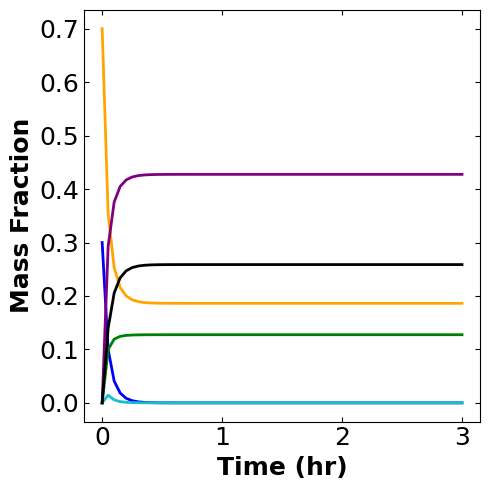

Mass fraction of species at the sample time: [[0.00010920931698981254, 0.18641711545169368, 1.2806031260458353e-05, 0.12749980006321715, 0.42738418773059406, 0.25857688140624496], [5.860815776969891e-11, 0.18624259026031528, 6.868518117291784e-12, 0.12751481965699138, 0.4275148195957846, 0.258727770421432], [2.8779700598978705e-14, 0.1862425901646263, 3.3396422192282763e-15, 0.12751481966382724, 0.4275148196673689, 0.2587277705041455]]

The output variables are:
              XA        XB            XC        XP        XE        XG
0  1.092093e-04  0.186417  1.280603e-05  0.127500  0.427384  0.258577
1  5.860816e-11  0.186243  6.868518e-12  0.127515  0.427515  0.258728
2  2.877970e-14  0.186243  3.339642e-15  0.127515  0.427515  0.258728


In [7]:
# define the constant temperature and sample time for mass fraction measurements
high_const_temp = 6.75
sample_time = [0.5, 1.5, 3]

# get the ground-truth simulation of the mass fractions
measured_var_high_temp = const_temp_reactor_model(0.3, high_const_temp, sample_time)

# make a dataframe of the measured variables
outputs_df_high_temp = ground_truth_data(measured_var_high_temp)

### Add Gaussian noise to the ground-truth simulations

In [8]:
# define the species
species = ["XA", "XB", "XC", "XP", "XE", "XG"]

# define the measurement error of the mass fraction measurements
std_dict = {
    "XA": 0.001,
    "XB": 0.001,
    "XC": 0.001,
    "XP": 0.01,
    "XE": 0.01,
    "XG": 0.01,
}

# generate the noisy mass fraction measurements
noisy_mass_frac_high = generate_noisy_mass_fraction(
    outputs_df_high_temp,
    species_cols=species,
    standard_dev=std_dict,
)

### Compile the generated data into a csv file

In [9]:
data_high_temp = synthetic_data_compiler(sample_time, noisy_mass_frac_high, 
                                         "batch_reactor_const_temp")

The generated data is:
    Time (hr)   XA        XB        XC        XP        XE        XG
0        0.5  0.0  0.190162  0.000872  0.125284  0.431844  0.251838
1        1.5  0.0  0.186815  0.000862  0.120495  0.428887  0.262941
2        3.0  0.0  0.193286  0.000493  0.123797  0.433298  0.249126


### Reformulate the batch reactor model for parameter estimation

In [10]:
def reform_const_temp_reactor_model(XA0, temp):
    """
    Reformulates the constant temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp: int or float,
        Constant reaction temperature in R

    Returns
    -------
    model: Pyomo model of the batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=(0, 1))
    model.T_reparam.fix(1/temp)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == m.alpha_1 - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == m.alpha_2 - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == m.alpha_3 - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

In [11]:
# create an experiment class for the high temperature data
exp_high = BatchReactorExperiment(
    data=data_high_temp, XA0=0.3,
    temp_control=high_const_temp,
    const_temp=True,
)

# estimate the parameters and the covariance matrix
obj_high, estimated_params_high, cov_matrix_high = parameter_covariance_est([exp_high], const_temp=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [12]:
print("Estimate of the parameters:\n", estimated_params_high)
print("\nCovariance matrix of the estimated parameters:\n", cov_matrix_high)

Estimate of the parameters:
 {'alpha_1': 25808.671055841358, 'alpha_2': 25808.286618029586, 'alpha_3': 25808.772915921294, 'E1': 174178.56972361924, 'E2': 174181.16386365524, 'E3': 174177.88240997196}

Covariance matrix of the estimated parameters:
               alpha_1       alpha_2       alpha_3            E1            E2  \
alpha_1 -2.149867e+13  2.938992e+12  3.436814e+12 -1.451160e+14  1.983820e+13   
alpha_2  5.013288e+12  6.850143e+11  7.578065e+10  3.383969e+13  4.623846e+12   
alpha_3  6.607953e+12  6.080109e+11 -8.005309e+11  4.460368e+13  4.104074e+12   
E1      -1.451160e+14  1.983820e+13  2.319849e+13 -9.795332e+14  1.339078e+14   
E2       3.383969e+13  4.623846e+12  5.115194e+11  2.284179e+14  3.121096e+13   
E3       4.460368e+13  4.104073e+12 -5.403584e+12  3.010749e+14  2.770250e+13   

                   E3  
alpha_1  2.319849e+13  
alpha_2  5.115194e+11  
alpha_3 -5.403584e+12  
E1       1.565898e+14  
E2       3.452756e+12  
E3      -3.647419e+13  


## Optimal reaction temperature to maximize main product P

In [13]:
def optimize_reactor_const_temp(XA0):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A

    Returns
    -------
    measured_variables: float or int, temperature that maximizes main product P formation
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1),)
    model.XB = pyo.Var(model.t, bounds=(0, 1),)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=[1/6.8, 1/5.8], initialize=1/6.3)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == pyo.log(m.a1) - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == pyo.log(m.a2) - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == pyo.log(m.a3) - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # initialize the initial mass fractions
    model.XA[0].set_value(XA0)
    model.XB[0].set_value(1-XA0)

    # fix the initial conditions
    t0 = model.t.first()
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # objective function
    model.obj = pyo.Objective(expr=model.XP[3], sense=pyo.maximize)
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    return pyo.value(model.XA[0]), 1 / pyo.value(model.T_reparam)

In [14]:
# get the optimal reaction temperature to maximize the main product
optimal_XA0_const, optimal_const_temp = optimize_reactor_const_temp(0.5)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [15]:
print("The optimal constant temperature is:", optimal_const_temp)
print("The optimal initial mass fraction of A is:", optimal_XA0_const)

The optimal constant temperature is: 5.8
The optimal initial mass fraction of A is: 0.3027330616496622


## Constant low (optimal) temperature batch reactor

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

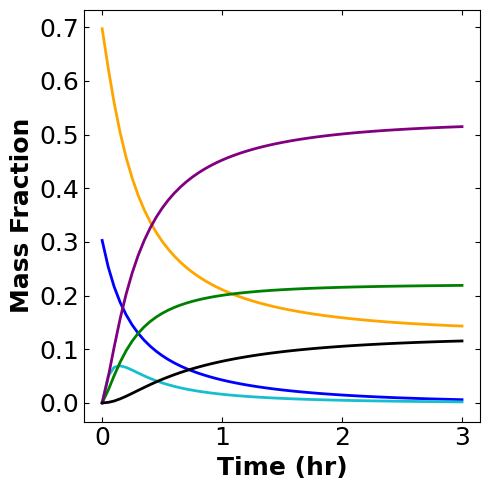

Mass fraction of species at the sample time: [[0.08808991652893243, 0.3012229095042101, 0.037300067246788776, 0.1668086558759034, 0.3628017674326466, 0.043776683409788276], [0.024151603054212937, 0.17604429406021263, 0.008365163123690207, 0.21088349424248798, 0.4852823713588913, 0.09527307416128215], [0.005953569248408566, 0.14309573424218366, 0.0018580476518458007, 0.21893295475307553, 0.5147834233943678, 0.11537627071111746]]

The output variables are:
          XA        XB        XC        XP        XE        XG
0  0.088090  0.301223  0.037300  0.166809  0.362802  0.043777
1  0.024152  0.176044  0.008365  0.210883  0.485282  0.095273
2  0.005954  0.143096  0.001858  0.218933  0.514783  0.115376


In [16]:
# get the ground-truth simulation of the mass fractions
measured_var_low_temp = const_temp_reactor_model(optimal_XA0_const, optimal_const_temp, 
                                                 sample_time, low_temp=True)

# make a dataframe of the measured variables
outputs_df_low_temp = ground_truth_data(measured_var_low_temp)

In [17]:
# generate the noisy mass fraction measurements
noisy_mass_frac_low = generate_noisy_mass_fraction(
    outputs_df_low_temp,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
data_low_temp = synthetic_data_compiler(sample_time, noisy_mass_frac_low, 
                                        "batch_reactor_const_temp_low")

The generated data is:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.088697  0.307418  0.038893  0.165492  0.366430  0.033070
1        1.5  0.023547  0.176701  0.009271  0.204381  0.487264  0.098836
2        3.0  0.005368  0.148658  0.002422  0.218785  0.524231  0.100536


In [18]:
# create an experiment class for the low temperature data
exp_low = BatchReactorExperiment(
    data=data_low_temp, XA0=optimal_XA0_const,
    temp_control=optimal_const_temp,
    const_temp=True,
)

# estimate the parameters and the covariance matrix
obj_low, estimated_params_low, cov_matrix_low = parameter_covariance_est([exp_low], const_temp=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [19]:
print("Estimate of the parameters:\n", estimated_params_low)
print("\nCovariance matrix of the estimated parameters:\n", cov_matrix_low)

Estimate of the parameters:
 {'alpha_1': 29412.663528107765, 'alpha_2': 29413.09362468206, 'alpha_3': 29412.94019737874, 'E1': 170583.02244877035, 'E2': 170580.52826700226, 'E3': 170581.4179918185}

Covariance matrix of the estimated parameters:
               alpha_1       alpha_2       alpha_3            E1            E2  \
alpha_1  6.042801e+11 -2.704589e+11 -1.998660e+11  3.504824e+12 -1.568662e+12   
alpha_2 -2.262092e+11 -2.589518e+11  2.075708e+11 -1.312013e+12 -1.501921e+12   
alpha_3 -2.057231e+11  1.045573e+11  1.144055e+12 -1.193194e+12  6.064325e+11   
E1       3.504824e+12 -1.568662e+12 -1.159223e+12  2.032798e+13 -9.098237e+12   
E2      -1.312013e+12 -1.501921e+12  1.203911e+12 -7.609677e+12 -8.711140e+12   
E3      -1.193194e+12  6.064325e+11  6.635517e+12 -6.920524e+12  3.517308e+12   

                   E3  
alpha_1 -1.159223e+12  
alpha_2  1.203911e+12  
alpha_3  6.635517e+12  
E1      -6.723493e+12  
E2       6.982682e+12  
E3       3.848600e+13  


## Parameter estimation for combined low and high temperature data

In [20]:
# combine the high and low temperature data
exp_list_comb = [exp_high, exp_low]

# estimate the parameters and the covariance matrix
obj_comb, estimated_params_comb, cov_matrix_comb = parameter_covariance_est(exp_list_comb,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [21]:
print("Estimate of the parameters:\n", estimated_params_comb)

print("\nCovariance matrix of the estimated parameters:\n", cov_matrix_comb)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(cov_matrix_comb)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(cov_matrix_comb)))

print("\nThe determinant of the Fisher information matrix is:\n", 
      np.linalg.det(np.linalg.inv(cov_matrix_comb)))

Estimate of the parameters:
 {'alpha_1': 20.561950114899904, 'alpha_2': 9.848585969123214, 'alpha_3': 18.63129266756243, 'E1': 108.83329644583576, 'E2': 41.70704291174759, 'E3': 94.42634483805502}

Covariance matrix of the estimated parameters:
            alpha_1     alpha_2     alpha_3          E1          E2          E3
alpha_1   8.039250   -9.324673  -10.176189   46.629225  -54.083904  -59.019008
alpha_2  -9.324673   23.309701   24.288963  -54.083904  135.211534  140.887571
alpha_3 -10.176189   24.288963   25.416035  -59.019008  140.887571  147.461199
E1       46.629225  -54.083904  -59.019008  270.460123 -313.692033 -342.290753
E2      -54.083904  135.211534  140.887571 -313.692033  784.329960  817.226121
E3      -59.019008  140.887571  147.461199 -342.290753  817.226121  855.600267
The condition number of the Fisher information matrix is:
 56236242.71346078

The trace of the Fisher information matrix is:
 41603.04615202811

The determinant of the Fisher information matrix is:
 11

In [22]:
print("\nThe Fisher information matrix is:\n", 
      np.linalg.inv(cov_matrix_comb))


The Fisher information matrix is:
 [[29046.66713338  3095.30798458 -2194.07388983 -5006.77972572
   -542.70540871   387.4408187 ]
 [ 3095.30798498  6766.24615356 -4502.83304953  -542.70540876
  -1081.3053589    691.09740571]
 [-2194.07389017 -4502.83304951  4642.62586714   387.44081875
    691.09740568  -715.13707662]
 [-5006.77972572  -542.70540869   387.44081869   863.05027904
     94.90791557   -68.15602516]
 [ -542.70540877 -1081.3053589    691.09740568    94.90791558
    173.79657984  -106.52463326]
 [  387.44081876   691.09740571  -715.13707662   -68.15602516
   -106.52463326   110.66013907]]


## Implement the temperature profile obtained from experimental design

### Low temperature data plus condition number design

In [23]:
# load the design conditions from optimal experimental design
cond_optimal_design = pd.read_csv("condition_number_optimal_design.csv")
cond_optimal_temp = cond_optimal_design["Temperature (1/R)"]
cond_optimal_XA0 = cond_optimal_design["XA"][0]
time_vals = cond_optimal_design["Time (hr)"]
print("The optimal XA0 for ME-optimality is:", cond_optimal_XA0)

The optimal XA0 for ME-optimality is: 0.3761878713385204


In [24]:
def optimal_exp_design_model(XA0, meas_sample_time, temp_profile,):
    """
    Creates a variable temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    meas_sample_time: list, 
        Timepoints (in hr) to collect samples for mass fraction measurements
    temp_profile: Pandas series or list,
        Temperature profile from optimal experimental design

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == pyo.log(m.a1) - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == pyo.log(m.a2) - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == pyo.log(m.a3) - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - XA0)
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=90, scheme="BACKWARD")

    # add the optimal temperature profile
    for indx, t in enumerate(time_vals):
        model.T_reparam[t].fix(temp_profile[indx])

    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [100 * (1 / pyo.value(model.T_reparam[t])) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig, ax1 = plt.subplots(figsize=(6.5, 5))

    # set the primary axis: mass fraction
    ax1.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    ax1.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    ax1.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    ax1.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    ax1.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    ax1.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    ax1.set_xlabel('Time (hr)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    ax1.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # set the secondary axis: temperature
    ax2 = ax1.twinx()
    ax2.plot(t_values, temp_values, "--", color='red', linewidth=3)
    ax2.set_ylabel(r'Temperature ($\mathbf{^{\circ}}$R)', color='red', fontsize=16, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=16, labelcolor='red', direction="in", top=True, right=True)

    # add legend
    plt.grid()
    ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

### Reformulate the batch reactor model for parameter estimation

In [25]:
def reform_optimal_exp_design_model(XA0, temp_profile):
    """
    Reformulates the variable temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp_profile: Pandas series or list,
        Temperature profile from optimal experimental design

    Returns
    -------
    model: Pyomo model of the variable temperature batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == m.alpha_1 - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == m.alpha_2 - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == m.alpha_3 - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)
    # model.dXP = dae.DerivativeVar(model.XP, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=90, scheme="BACKWARD")

    # add the optimal temperature profile
    for indx, t in enumerate(time_vals):
        model.T_reparam[t].fix(temp_profile[indx])
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

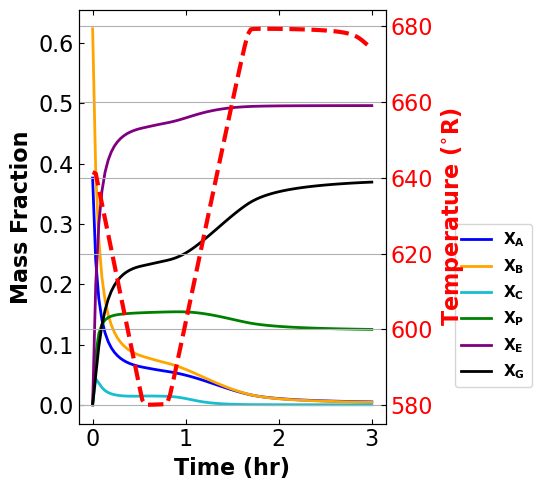

Mass fraction of species at the sample time: [[0.06365351286910008, 0.08235278983063933, 0.014351321957744417, 0.15249126323229178, 0.45784996072284, 0.22930115138738444], [0.024702220504325606, 0.025870614413750836, 0.0009141469837312723, 0.14188314948473882, 0.49291172682706835, 0.31371814178638524], [0.00481435320621306, 0.004234252591767709, 2.801298704498992e-05, 0.1250492042360239, 0.4964087158748095, 0.3694654611041409]]

The output variables are:
          XA        XB        XC        XP        XE        XG
0  0.063654  0.082353  0.014351  0.152491  0.457850  0.229301
1  0.024702  0.025871  0.000914  0.141883  0.492912  0.313718
2  0.004814  0.004234  0.000028  0.125049  0.496409  0.369465
The generated data is:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.063780  0.084244  0.015493  0.150893  0.463347  0.222242
1        1.5  0.024101  0.025754  0.001781  0.135025  0.494933  0.318406
2        3.0  0.004186  0.004526  0.000522  0.121

In [26]:
# get the ground-truth simulation of the mass fractions
cond_measured_var = optimal_exp_design_model(cond_optimal_XA0, sample_time, 
                                            temp_profile=cond_optimal_temp)

# make a dataframe of the measured variables
cond_measured_var_df = ground_truth_data(cond_measured_var)

# generate the noisy mass fraction measurements
cond_noisy_mass_frac_var = generate_noisy_mass_fraction(
    cond_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
cond_data_var = synthetic_data_compiler(sample_time, cond_noisy_mass_frac_var, 
                                       "batch_reactor_cond_optimal_design")

In [27]:
# create an experiment class for the data from optimal experiment design
cond_exp = BatchReactorExperiment(
    data=cond_data_var, XA0=cond_optimal_XA0,
    temp_control=cond_optimal_temp,
    const_temp=False,
    doe_solve=True,
)

# combine the low temperature and optimal experiment design data
cond_exp_list = [exp_low, cond_exp]

# estimate the parameters and the covariance matrix
cond_obj, cond_theta_opt, cond_cov_matrix = parameter_covariance_est(cond_exp_list,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [28]:
print("Estimates of the original parameters:\n", cond_theta_opt)

print("\nCovariance matrix of the estimated parameters:\n", cond_cov_matrix)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(cond_cov_matrix)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(cond_cov_matrix)))

print("\nThe determinant of the Fisher information matrix is:\n", 
      np.linalg.det(np.linalg.inv(cond_cov_matrix)))

Estimates of the original parameters:
 {'alpha_1': 22.61231289423599, 'alpha_2': 26.990255387095512, 'alpha_3': 34.18075405360507, 'E1': 120.72636339973391, 'E2': 141.12930132508694, 'E3': 184.61136056405678}

Covariance matrix of the estimated parameters:
           alpha_1    alpha_2    alpha_3        E1          E2          E3
alpha_1  0.038780   0.077959   0.099106  0.228323    0.452274    0.583192
alpha_2  0.077959   3.589138   3.659060  0.448422   20.884898   21.306451
alpha_3  0.099106   3.659060   4.027360  0.578456   21.282251   23.518486
E1       0.228323   0.448422   0.578456  1.345480    2.600726    3.406354
E2       0.452274  20.884898  21.282251  2.600726  121.540646  123.934565
E3       0.583192  21.306451  23.518486  3.406354  123.934565  137.379446
The condition number of the Fisher information matrix is:
 10072960.23251261

The trace of the Fisher information matrix is:
 46118.713980146546

The determinant of the Fisher information matrix is:
 153311489.21728882


### High temperature data plus condition number design

In [29]:
# combine the high temperature and optimal experiment design data
cond_exp_list_2 = [exp_high, cond_exp]

# estimate the parameters and the covariance matrix
cond_obj_2, cond_theta_opt_2, cond_cov_matrix_2 = parameter_covariance_est(cond_exp_list_2,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [30]:
print("Estimates of the original parameters:\n", cond_theta_opt_2)

print("\nCovariance matrix of the estimated parameters:\n", cond_cov_matrix_2)

# get the scalar metrics of the Fisher information matrix
print("The condition number of the Fisher information matrix is:\n", 
      np.linalg.cond(np.linalg.inv(cond_cov_matrix_2)))

print("\nThe trace of the Fisher information matrix is:\n", 
      np.trace(np.linalg.inv(cond_cov_matrix_2)))

print("\nThe determinant of the Fisher information matrix is:\n", 
      np.linalg.det(np.linalg.inv(cond_cov_matrix_2)))

Estimates of the original parameters:
 {'alpha_1': 24.3817708242814, 'alpha_2': 25.334402394832587, 'alpha_3': 34.68580131684343, 'E1': 131.76611963999565, 'E2': 131.34743334267108, 'E3': 188.43084086139055}

Covariance matrix of the estimated parameters:
            alpha_1     alpha_2     alpha_3          E1           E2  \
alpha_1   3.662790   -0.574450   -0.746639   22.810523    -2.722179   
alpha_2  -0.574450   41.106438   40.666882   -4.128052   246.485757   
alpha_3  -0.746639   40.666882   40.391942   -5.189326   243.800919   
E1       22.810523   -4.128052   -5.189326  142.068139   -20.254192   
E2       -2.722179  246.485757  243.800919  -20.254192  1478.261000   
E3       -3.569865  243.803115  242.181894  -25.464076  1461.908039   

                  E3  
alpha_1    -3.569865  
alpha_2   243.803115  
alpha_3   242.181894  
E1        -25.464076  
E2       1461.908039  
E3       1452.457547  
The condition number of the Fisher information matrix is:
 30871794.782523297

The t

## Generate the confidence regions

In [31]:
def likelihood_confidence_ellipse(opt_design_params, opt_design_cov, 
                                  param_index, confidence_level=0.80, 
                                  grid_points=300,):
    # define the parameters and covariance from the low and 
    # optimal design using numpy
    theta_hat_low_opt = np.array([
        opt_design_params["alpha_1"],
        opt_design_params["alpha_2"],
        opt_design_params["alpha_3"],
        opt_design_params["E1"],
        opt_design_params["E2"],
        opt_design_params["E3"]
    ])
    cov_low_opt = opt_design_cov.to_numpy()

    # define the parameters and covariance from the combined low and high
    theta_hat_comb = np.array([
        estimated_params_comb["alpha_1"], 
        estimated_params_comb["alpha_2"], 
        estimated_params_comb["alpha_3"],
        estimated_params_comb["E1"], 
        estimated_params_comb["E2"], 
        estimated_params_comb["E3"]])
    cov_comb = cov_matrix_comb.to_numpy()

    # define the parameters and covariance from the high and 
    # optimal design using numpy
    theta_hat_high_opt = np.array([
        cond_theta_opt_2["alpha_1"], 
        cond_theta_opt_2["alpha_2"], 
        cond_theta_opt_2["alpha_3"],
        cond_theta_opt_2["E1"], 
        cond_theta_opt_2["E2"], 
        cond_theta_opt_2["E3"]])
    cov_high_opt = cond_cov_matrix_2.to_numpy()
    
    # get the parameters of interest
    theta_sub_low_opt = theta_hat_low_opt[param_index]
    theta_sub_comb = theta_hat_comb[param_index]
    theta_sub_high_opt = theta_hat_high_opt[param_index]
    
    # get the covariance matrix of interest
    cov_sub_low_opt = cov_low_opt[np.ix_(param_index, param_index)]
    cov_sub_inv_low_opt = np.linalg.inv(cov_sub_low_opt)
    
    cov_sub_comb = cov_comb[np.ix_(param_index, param_index)]
    cov_sub_inv_comb = np.linalg.inv(cov_sub_comb)
    
    cov_sub_high_opt = cov_high_opt[np.ix_(param_index, param_index)]
    cov_sub_inv_high_opt = np.linalg.inv(cov_sub_high_opt)
    
    # define the chi-squared threshold
    cutoff = chi2.ppf(confidence_level, df=2)
    
    # define the grid of the parameters from the low and optimal design
    param_1_grid = np.linspace(
        theta_sub_low_opt[0] - 4 * np.sqrt(cov_sub_low_opt[0,0]),
        theta_sub_low_opt[0] + 4 * np.sqrt(cov_sub_low_opt[0,0]),
        grid_points
    )
    
    param_2_grid = np.linspace(
        theta_sub_low_opt[1] - 4 * np.sqrt(cov_sub_low_opt[1,1]),
        theta_sub_low_opt[1] + 4 * np.sqrt(cov_sub_low_opt[1,1]),
        grid_points
    )
    
    A, B = np.meshgrid(param_1_grid, param_2_grid)
    
    # define the grid of the parameters from the combined low and high
    param_1_grid_comb = np.linspace(
        theta_sub_comb[0] - 4 * np.sqrt(cov_sub_comb[0,0]),
        theta_sub_comb[0] + 4 * np.sqrt(cov_sub_comb[0,0]),
        grid_points
    )
    
    param_2_grid_comb = np.linspace(
        theta_sub_comb[1] - 4 * np.sqrt(cov_sub_comb[1,1]),
        theta_sub_comb[1] + 4 * np.sqrt(cov_sub_comb[1,1]),
        grid_points
    )
    
    A_comb, B_comb = np.meshgrid(param_1_grid_comb, param_2_grid_comb)
    
    # define the grid of the parameters from the high and optimal design
    param_1_grid_high_opt = np.linspace(
        theta_sub_high_opt[0] - 4 * np.sqrt(cov_sub_high_opt[0,0]),
        theta_sub_high_opt[0] + 4 * np.sqrt(cov_sub_high_opt[0,0]),
        grid_points
    )
    
    param_2_grid_high_opt = np.linspace(
        theta_sub_high_opt[1] - 4 * np.sqrt(cov_sub_high_opt[1,1]),
        theta_sub_high_opt[1] + 4 * np.sqrt(cov_sub_high_opt[1,1]),
        grid_points
    )
    
    A_high_opt, B_high_opt = np.meshgrid(param_1_grid_high_opt, param_2_grid_high_opt)
    
    # compute the likelihood ratio statistics
    LR_stats = np.zeros_like(A)
    LR_stats_comb = np.zeros_like(A_comb)
    LR_stats_high_opt = np.zeros_like(A_high_opt)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            # compute the difference between the current parameters 
            # and the estimated parameters
            d = np.array([
                A[i,j] - theta_sub_low_opt[0],
                B[i,j] - theta_sub_low_opt[1]
            ])
            d_comb = np.array([
                A_comb[i,j] - theta_sub_comb[0],
                B_comb[i,j] - theta_sub_comb[1]
            ])
    
            d_high_opt = np.array([
                A_high_opt[i,j] - theta_sub_high_opt[0],
                B_high_opt[i,j] - theta_sub_high_opt[1]
            ])

            # update the likelihood ratio statistics
            LR_stats[i,j] = d @ cov_sub_inv_low_opt @ d
            LR_stats_comb[i,j] = d_comb @ cov_sub_inv_comb @ d_comb
            LR_stats_high_opt[i,j] = d_high_opt @ cov_sub_inv_high_opt @ d_high_opt

    return cutoff, np.array([[A_high_opt, B_high_opt, LR_stats_high_opt], 
                             [A_comb, B_comb, LR_stats_comb], [A, B, LR_stats]])
    
    

In [32]:
def plot_confidence_region(cutoff, LR_mat, labels, fig_name):
    fig = plt.subplots(figsize=(5, 5))

    # high and optimal design color
    high_opt_fill = "#92C5DE"
    high_opt_edge = "#0571B0"
    
    # combined low and high color
    comb_fill = "#F4A582"
    comb_edge = "#D6604D"
    
    # low and optimal design color
    low_opt_fill = "#B8E186"
    low_opt_edge = "#4D9221"
    
    alpha_fill = 0.25
    lw = 2.5
    
    # plot the confidence regions
    plt.contourf(LR_mat[0,0], LR_mat[0,1], np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                 levels=[0.5, 1.5], colors=[high_opt_fill], alpha=alpha_fill)
    
    plt.contourf(LR_mat[1,0], LR_mat[1,1], np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                 levels=[0.5, 1.5], colors=[comb_fill], alpha=alpha_fill)
    
    plt.contourf(LR_mat[2,0], LR_mat[2,1], np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                 levels=[0.5, 1.5], colors=[low_opt_fill], alpha=alpha_fill)
    
    # plot the boundaries of the confidence regions
    plt.contour(LR_mat[0,0], LR_mat[0,1], LR_mat[0,2], 
                levels=[cutoff], colors=[high_opt_edge], linewidths=lw,)

    plt.contour(LR_mat[1,0], LR_mat[1,1], LR_mat[1,2], 
                levels=[cutoff], colors=[comb_edge], linewidths=lw,)
    
    plt.contour(LR_mat[2,0], LR_mat[2,1], LR_mat[2,2], 
                levels=[cutoff], colors=[low_opt_edge], linewidths=lw,)

    if fig_name == ["E1", "E3"]:
        # plot the true value of the parameters
        plt.scatter(true_params["E1"], true_params["E3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((70, 170))
        plt.ylim((25, 275))

        # high temp + ME-opt
        plt.scatter(
            cond_theta_opt_2["E1"],
            cond_theta_opt_2["E3"],
            color=high_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low + high temp
        plt.scatter(
            estimated_params_comb["E1"],
            estimated_params_comb["E3"],
            color=comb_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low temp + ME-opt
        plt.scatter(
            cond_theta_opt["E1"],
            cond_theta_opt["E3"],
            color=low_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
    elif fig_name == ["E1", "E2"]:
        plt.scatter(true_params["E1"], true_params["E2"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((70, 170))
        plt.ylim((-20, 220))

        # high temp + ME-opt
        plt.scatter(
            cond_theta_opt_2["E1"],
            cond_theta_opt_2["E2"],
            color=high_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low + high temp
        plt.scatter(
            estimated_params_comb["E1"],
            estimated_params_comb["E2"],
            color=comb_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low temp + ME-opt
        plt.scatter(
            cond_theta_opt["E1"],
            cond_theta_opt["E2"],
            color=low_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
    elif fig_name == ["E2", "E3"]:
        plt.scatter(true_params["E2"], true_params["E3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((-30, 220))
        plt.ylim((25, 275))

        # high temp + ME-opt
        plt.scatter(
            cond_theta_opt_2["E2"],
            cond_theta_opt_2["E3"],
            color=high_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low + high temp
        plt.scatter(
            estimated_params_comb["E2"],
            estimated_params_comb["E3"],
            color=comb_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low temp + ME-opt
        plt.scatter(
            cond_theta_opt["E2"],
            cond_theta_opt["E3"],
            color=low_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
            
    elif fig_name == ["alpha_1", "alpha_2"]:
        plt.scatter(true_params["alpha_1"], true_params["alpha_2"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((15, 29))
        plt.ylim((-2, 39))

        # high temp + ME-opt
        plt.scatter(
            cond_theta_opt_2["alpha_1"],
            cond_theta_opt_2["alpha_2"],
            color=high_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low + high temp
        plt.scatter(
            estimated_params_comb["alpha_1"],
            estimated_params_comb["alpha_2"],
            color=comb_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low temp + ME-opt
        plt.scatter(
            cond_theta_opt["alpha_1"],
            cond_theta_opt["alpha_2"],
            color=low_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
            
    elif fig_name == ["alpha_1", "alpha_3"]:
        plt.scatter(true_params["alpha_1"], true_params["alpha_3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((15, 29))
        plt.ylim((5, 49))

        # high temp + ME-opt
        plt.scatter(
            cond_theta_opt_2["alpha_1"],
            cond_theta_opt_2["alpha_3"],
            color=high_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low + high temp
        plt.scatter(
            estimated_params_comb["alpha_1"],
            estimated_params_comb["alpha_3"],
            color=comb_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low temp + ME-opt
        plt.scatter(
            cond_theta_opt["alpha_1"],
            cond_theta_opt["alpha_3"],
            color=low_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
            
    elif fig_name == ["alpha_2", "alpha_3"]:
        plt.scatter(true_params["alpha_2"], true_params["alpha_3"], marker="*", 
                    color="black", s=220, zorder=100, label="True Value")
        plt.xlim((-2, 39))
        plt.ylim((5, 49))

        # high temp + ME-opt
        plt.scatter(
            cond_theta_opt_2["alpha_2"],
            cond_theta_opt_2["alpha_3"],
            color=high_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low + high temp
        plt.scatter(
            estimated_params_comb["alpha_2"],
            estimated_params_comb["alpha_3"],
            color=comb_edge,
            s=40,
            zorder=90,
            marker="o"
        )
        
        # low temp + ME-opt
        plt.scatter(
            cond_theta_opt["alpha_2"],
            cond_theta_opt["alpha_3"],
            color=low_opt_edge,
            s=40,
            zorder=90,
            marker="o"
        )

    # format the axis to look good
    plt.xlabel(labels[0], fontsize=18, fontweight="bold")
    plt.ylabel(labels[1], fontsize=18, fontweight="bold")
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.tick_params(direction="in",top=True, right=True)
    
    # # add the legend for the confidence ellipse
    # legend_elements = [
    #     Patch(facecolor=comb_fill, edgecolor=comb_edge, label='Low + High Temp Experiments'),
    #     Patch(facecolor=high_opt_fill, edgecolor=high_opt_edge, label='High Temp + ME-opt Experiments'),
    #     Patch(facecolor=low_opt_fill, edgecolor=low_opt_edge, label='Low Temp + ME-opt Experiments'),
    #     mlines.Line2D([], [], color='black', marker='*', linestyle='None', markersize=12, 
    #                   label='True Parameter Values'),
    #     mlines.Line2D([], [], color='black', marker='o', linestyle='None', 
    #                   markersize=8, label='Estimated Values'),
    # ]
    
    # plt.legend(handles=legend_elements, 
    #            prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1, 1.2), frameon=False)
    
    plt.tight_layout()
    plt.savefig(f"confidence_region_{fig_name[0]}_{fig_name[1]}.png", dpi=600, bbox_inches="tight")
    plt.show()

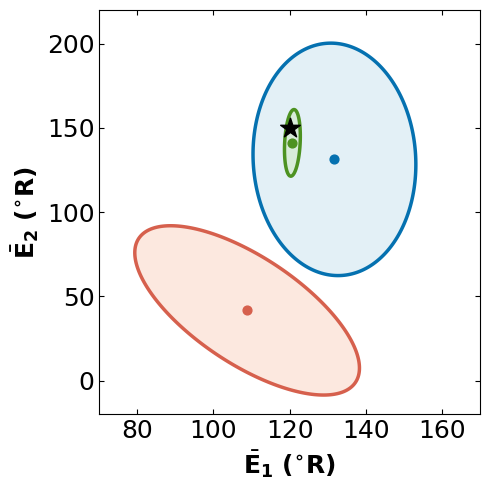

In [33]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[3, 4],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{E}}$$\mathbf{_1}$ ($\mathbf{^{\circ}}$R)",
                                               r"$\bar{\mathbf{E}}$$\mathbf{_2}$ ($\mathbf{^{\circ}}$R)"], 
                       fig_name=["E1", "E2"])

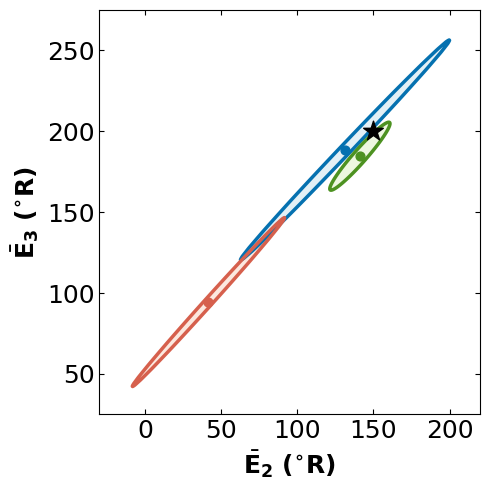

In [34]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[4, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{E}}$$\mathbf{_2}$ ($\mathbf{^{\circ}}$R)",
                                               r"$\bar{\mathbf{E}}$$\mathbf{_3}$ ($\mathbf{^{\circ}}$R)"], 
                      fig_name=["E2", "E3"])

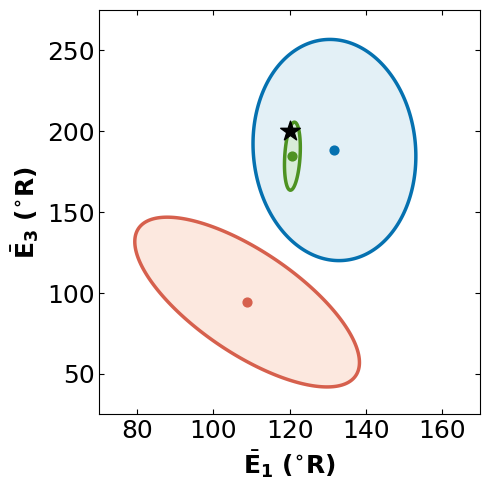

In [35]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[3, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{E}}$$\mathbf{_1}$ ($\mathbf{^{\circ}}$R)",
                                               r"$\bar{\mathbf{E}}$$\mathbf{_3}$ ($\mathbf{^{\circ}}$R)"], 
                      fig_name=["E1", "E3"])

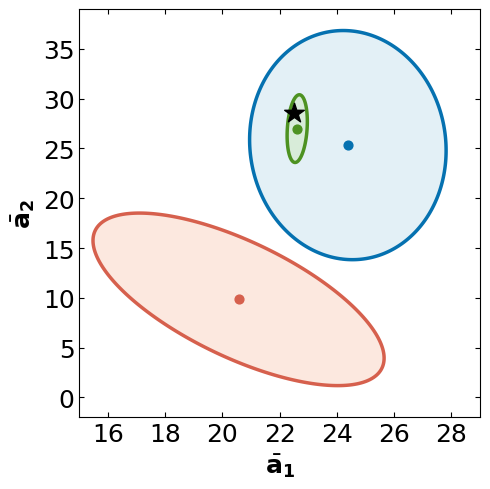

In [36]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[0, 1],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{a}}$$\mathbf{_1}$", 
                                               r"$\bar{\mathbf{a}}$$\mathbf{_2}$"], 
                       fig_name=["alpha_1", "alpha_2"])

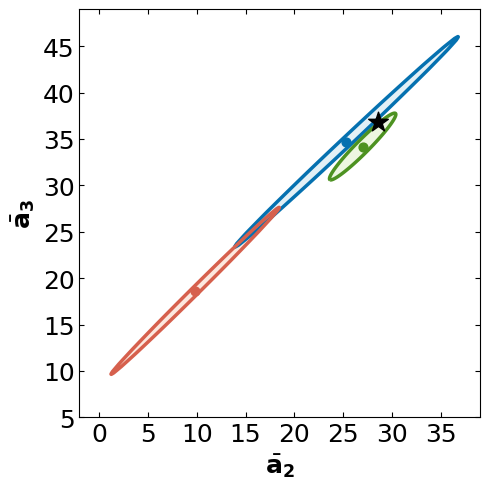

In [37]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[1, 2],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{a}}$$\mathbf{_2}$", 
                                               r"$\bar{\mathbf{a}}$$\mathbf{_3}$"], 
                       fig_name=["alpha_2", "alpha_3"])

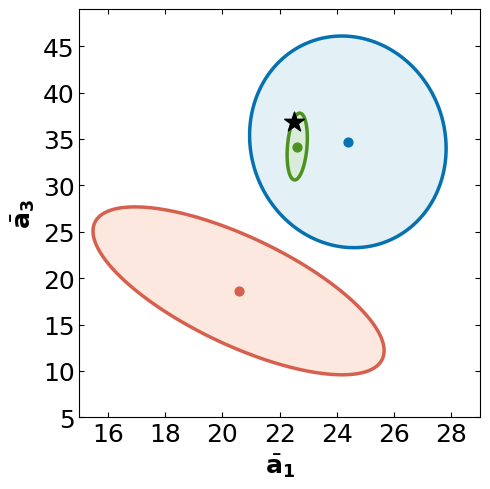

In [38]:
cutoff, LR_mat = likelihood_confidence_ellipse(cond_theta_opt, cond_cov_matrix, 
                                               param_index=[0, 2],)

plot_confidence_region(cutoff, LR_mat, labels=[r"$\bar{\mathbf{a}}$$\mathbf{_1}$", 
                                               r"$\bar{\mathbf{a}}$$\mathbf{_3}$"], 
                       fig_name=["alpha_1", "alpha_3"])